# Binární problém


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def onemax(individual):
    return sum(individual)

def leading_ones(individual):
    count = 0
    for bit in individual:
        if bit == 1:
            count += 1
        else:
            break
    return count

def selection_roulette(population, fitnesses):
    total_fit = sum(fitnesses)
    if total_fit == 0:
        return list(random.choice(population))
    pick = random.uniform(0, total_fit)
    current = 0
    for ind, fit in zip(population, fitnesses):
        current += fit
        if current >= pick:
            return list(ind)
    return list(population[-1])

def selection_rank(population, fitnesses):
    n = len(population)
    indexed = sorted(range(n), key=lambda i: fitnesses[i])
    total_rank = n * (n + 1) // 2
    pick = random.uniform(0, total_rank)
    current = 0
    for rank, idx in enumerate(indexed, start=1):
        current += rank
        if current >= pick:
            return list(population[idx])
    return list(population[indexed[-1]])

def crossover_one_point(parent1, parent2):
    length = len(parent1)
    if length <= 1:
        return list(parent1), list(parent2)
    point = random.randint(1, length - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

def mutate(individual, mutation_rate):
    return [1 - bit if random.random() < mutation_rate else bit for bit in individual]


In [2]:
def run_genetic_algorithm(fitness_fn, dim, max_evals, pop_size=50, elite_ratio=0.1, 
                           mutation_rate=0.01, crossover_rate=0.9, selection_type="rank"):
    population = [[random.randint(0, 1) for _ in range(dim)] for _ in range(pop_size)]
    fitnesses = [fitness_fn(ind) for ind in population]
    eval_count = pop_size

    select_parent = selection_rank if selection_type == "rank" else selection_roulette
    elite_count = max(1, int(pop_size * elite_ratio))

    best_so_far = max(fitnesses)
    convergence = [best_so_far] * eval_count

    while eval_count < max_evals:
        sorted_indices = sorted(range(pop_size), key=lambda i: fitnesses[i], reverse=True)
        new_population = [list(population[i]) for i in sorted_indices[:elite_count]]
        new_fitnesses = [fitnesses[i] for i in sorted_indices[:elite_count]]

        while len(new_population) < pop_size:
            p1 = select_parent(population, fitnesses)
            p2 = select_parent(population, fitnesses)
            
            if random.random() < crossover_rate:
                c1, c2 = crossover_one_point(p1, p2)
            else:
                c1, c2 = list(p1), list(p2)

            c1 = mutate(c1, mutation_rate)
            c2 = mutate(c2, mutation_rate)

            new_population.append(c1)
            if len(new_population) < pop_size:
                new_population.append(c2)

        population = new_population
        remaining = max_evals - eval_count
        offspring_to_eval = min(pop_size - elite_count, remaining)

        for i in range(elite_count, elite_count + offspring_to_eval):
            fit = fitness_fn(population[i])
            new_fitnesses.append(fit)
            eval_count += 1
            if fit > best_so_far:
                best_so_far = fit
            convergence.append(best_so_far)

        if offspring_to_eval < (pop_size - elite_count):
            break

        fitnesses = new_fitnesses

    if len(convergence) < max_evals:
        convergence.extend([best_so_far] * (max_evals - len(convergence)))
    else:
        convergence = convergence[:max_evals]

    return convergence, best_so_far


## Vliv velikosti populace


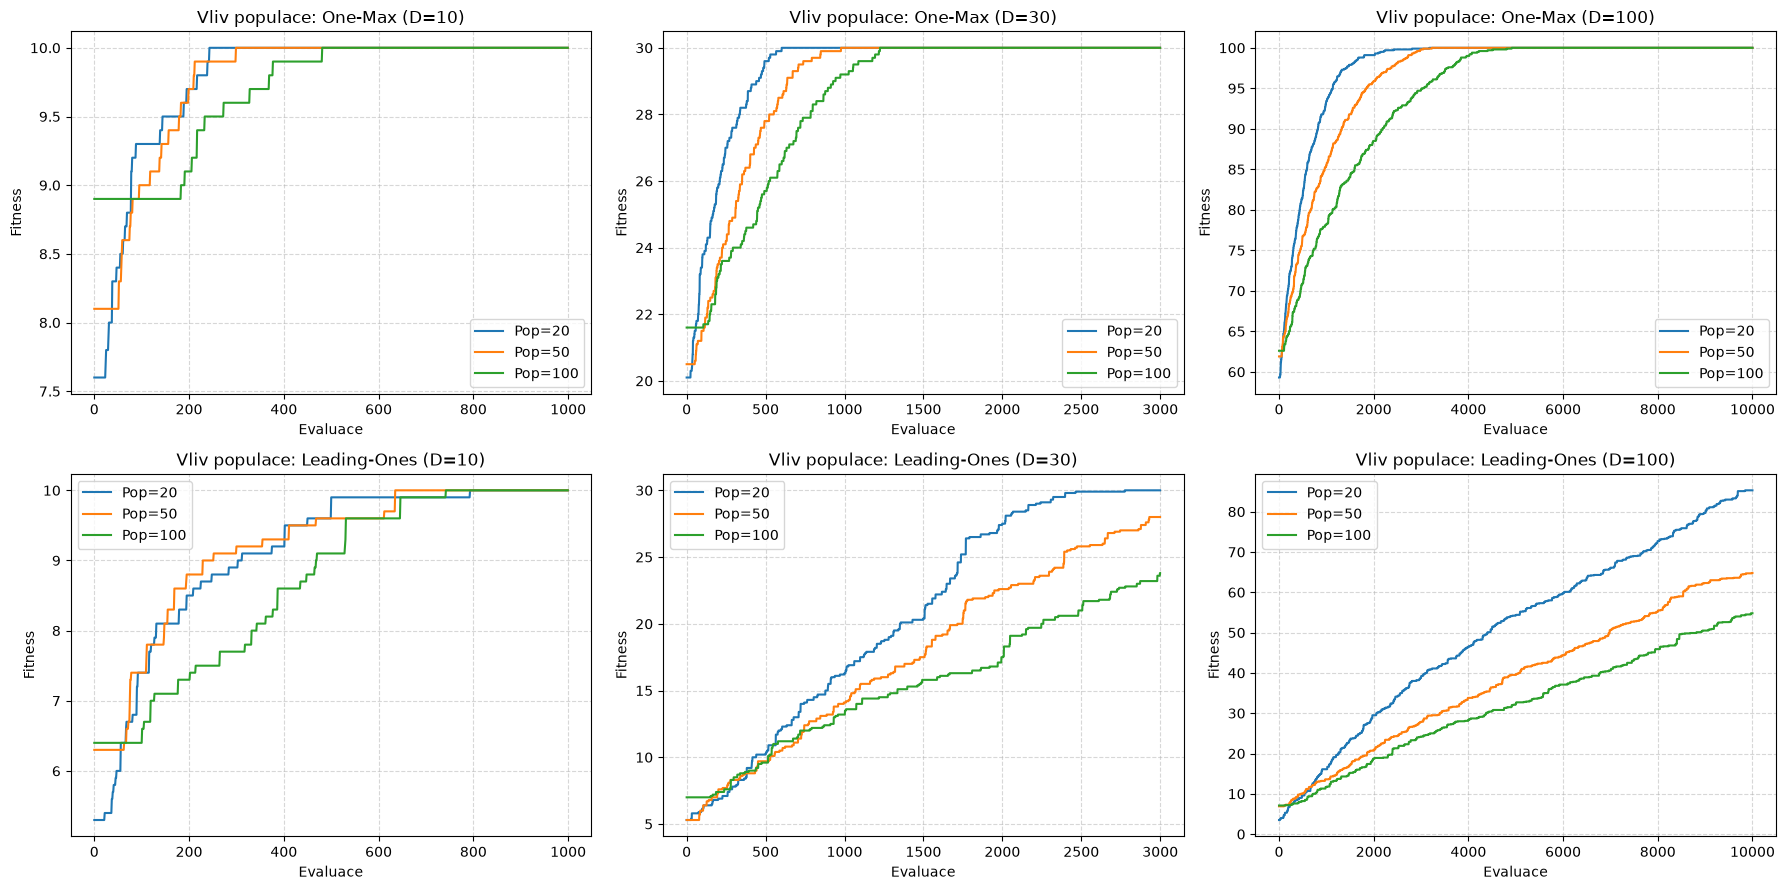

,Problém,Dimenze,Nastavení,Nejlepší,Nejhorší,Průměr,Medián,Směr. odchylka
0,One-Max,10,Pop=20,10,10,10.0,10.0,0.000000
1,One-Max,10,Pop=50,10,10,10.0,10.0,0.000000
2,One-Max,10,Pop=100,10,10,10.0,10.0,0.000000
3,One-Max,30,Pop=20,30,30,30.0,30.0,0.000000
4,One-Max,30,Pop=50,30,30,30.0,30.0,0.000000
5,One-Max,30,Pop=100,30,30,30.0,30.0,0.000000
6,One-Max,100,Pop=20,100,100,100.0,100.0,0.000000
7,One-Max,100,Pop=50,100,100,100.0,100.0,0.000000
8,One-Max,100,Pop=100,100,100,100.0,100.0,0.000000
9,Leading-Ones,10,Pop=20,10,10,10.0,10.0,0.000000


In [3]:
dimensions = [10, 30, 100]
num_runs = 10
problems = {"One-Max": onemax, "Leading-Ones": leading_ones}
pop_variants = [20, 50, 100]

fig, axes = plt.subplots(len(problems), len(dimensions), figsize=(18, 9))
best_pop_results = {}
pop_stats_records = []

for p_idx, (p_name, p_fn) in enumerate(problems.items()):
    for d_idx, dim in enumerate(dimensions):
        max_evals = 100 * dim
        ax = axes[p_idx, d_idx]
        best_mean = -1
        best_cfg = None
        
        for pop_size in pop_variants:
            runs_convergence = []
            runs_scores = []
            for _ in range(num_runs):
                conv, best_val = run_genetic_algorithm(
                    fitness_fn=p_fn, dim=dim, max_evals=max_evals,
                    pop_size=pop_size, elite_ratio=0.15, mutation_rate=0.01,
                    crossover_rate=0.9, selection_type="rank"
                )
                runs_convergence.append(conv)
                runs_scores.append(best_val)
                
            mean_conv = np.mean(runs_convergence, axis=0)
            ax.plot(mean_conv, label=f"Pop={pop_size}")
            
            m_score = np.mean(runs_scores)
            if m_score > best_mean:
                best_mean = m_score
                best_cfg = pop_size
                
            pop_stats_records.append({
                "Problém": p_name,
                "Dimenze": dim,
                "Nastavení": f"Pop={pop_size}",
                "Nejlepší": np.max(runs_scores),
                "Nejhorší": np.min(runs_scores),
                "Průměr": np.mean(runs_scores),
                "Medián": np.median(runs_scores),
                "Směr. odchylka": np.std(runs_scores)
            })
                
        best_pop_results[(p_name, dim)] = (best_cfg, best_mean)
        ax.set_title(f"Vliv populace: {p_name} (D={dim})")
        ax.set_xlabel("Evaluace")
        ax.set_ylabel("Fitness")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend()

plt.tight_layout()
plt.show()

df_pop_summary = pd.DataFrame(pop_stats_records)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
display(df_pop_summary)


## Vliv elitismu


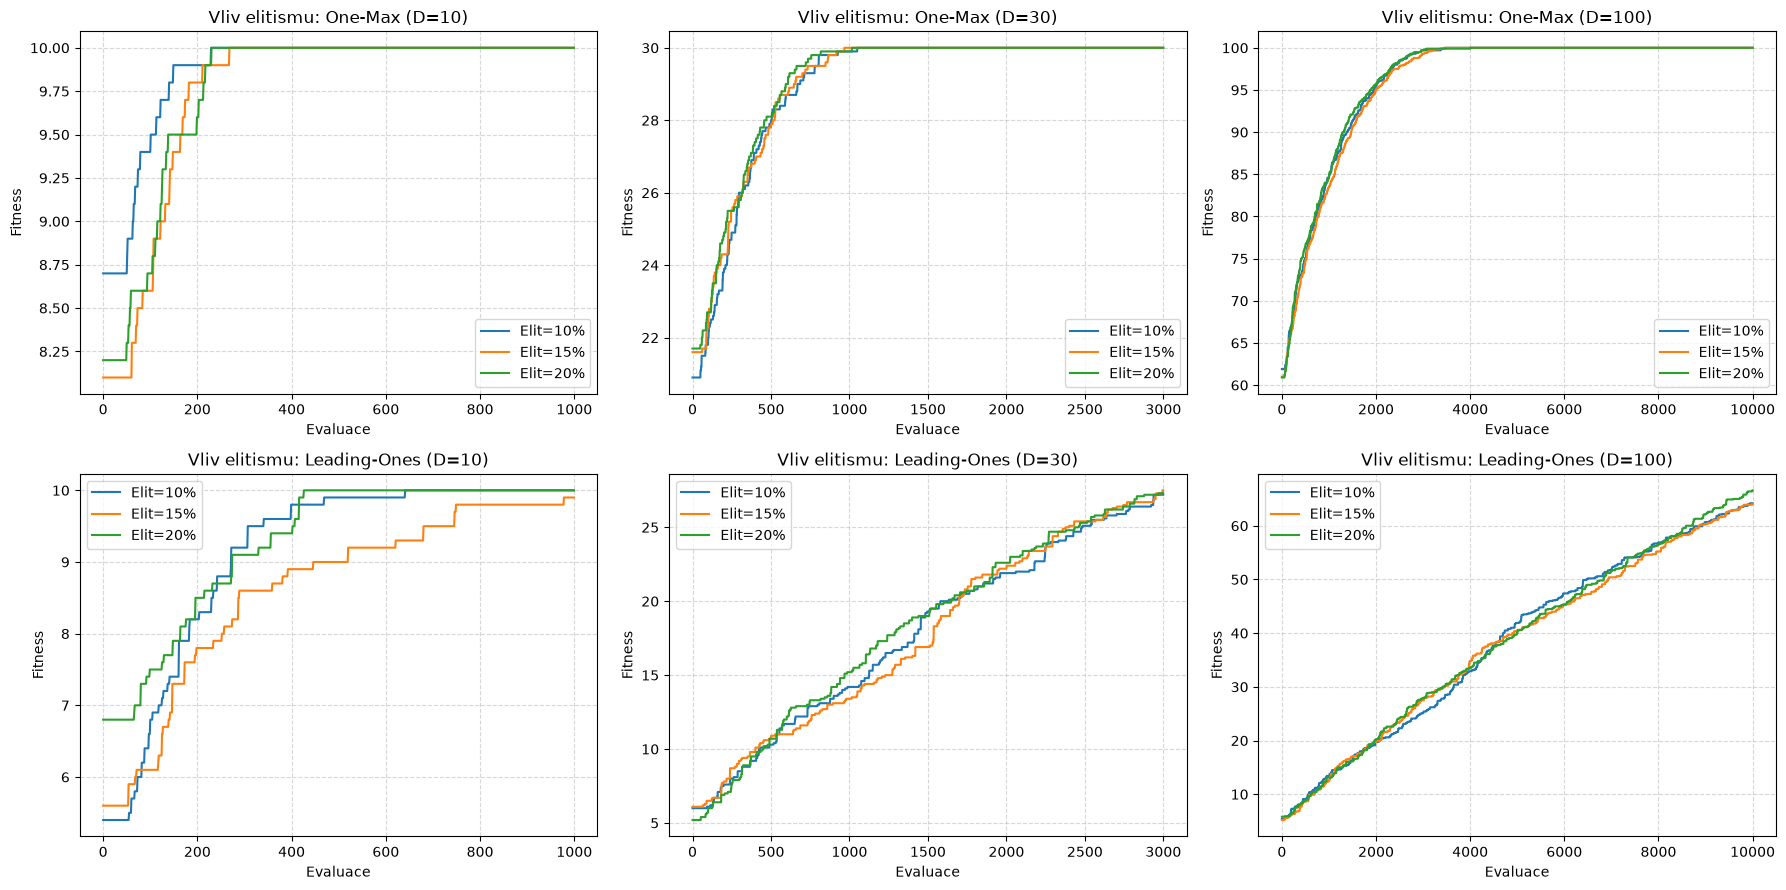

,Problém,Dimenze,Nastavení,Nejlepší,Nejhorší,Průměr,Medián,Směr. odchylka
0,One-Max,10,Elitismus=10%,10,10,10.0,10.0,0.000000
1,One-Max,10,Elitismus=15%,10,10,10.0,10.0,0.000000
2,One-Max,10,Elitismus=20%,10,10,10.0,10.0,0.000000
3,One-Max,30,Elitismus=10%,30,30,30.0,30.0,0.000000
4,One-Max,30,Elitismus=15%,30,30,30.0,30.0,0.000000
5,One-Max,30,Elitismus=20%,30,30,30.0,30.0,0.000000
6,One-Max,100,Elitismus=10%,100,100,100.0,100.0,0.000000
7,One-Max,100,Elitismus=15%,100,100,100.0,100.0,0.000000
8,One-Max,100,Elitismus=20%,100,100,100.0,100.0,0.000000
9,Leading-Ones,10,Elitismus=10%,10,10,10.0,10.0,0.000000


In [4]:
elite_variants = [0.10, 0.15, 0.20]
fig, axes = plt.subplots(len(problems), len(dimensions), figsize=(18, 9))
best_elite_results = {}
elite_stats_records = []

for p_idx, (p_name, p_fn) in enumerate(problems.items()):
    for d_idx, dim in enumerate(dimensions):
        max_evals = 100 * dim
        ax = axes[p_idx, d_idx]
        best_mean = -1
        best_cfg = None
        
        for elite_ratio in elite_variants:
            runs_convergence = []
            runs_scores = []
            for _ in range(num_runs):
                conv, best_val = run_genetic_algorithm(
                    fitness_fn=p_fn, dim=dim, max_evals=max_evals,
                    pop_size=50, elite_ratio=elite_ratio, mutation_rate=0.01,
                    crossover_rate=0.9, selection_type="rank"
                )
                runs_convergence.append(conv)
                runs_scores.append(best_val)
                
            mean_conv = np.mean(runs_convergence, axis=0)
            ax.plot(mean_conv, label=f"Elit={int(elite_ratio*100)}%")
            
            m_score = np.mean(runs_scores)
            if m_score > best_mean:
                best_mean = m_score
                best_cfg = elite_ratio
                
            elite_stats_records.append({
                "Problém": p_name,
                "Dimenze": dim,
                "Nastavení": f"Elitismus={int(elite_ratio*100)}%",
                "Nejlepší": np.max(runs_scores),
                "Nejhorší": np.min(runs_scores),
                "Průměr": np.mean(runs_scores),
                "Medián": np.median(runs_scores),
                "Směr. odchylka": np.std(runs_scores)
            })
                
        best_elite_results[(p_name, dim)] = (best_cfg, best_mean)
        ax.set_title(f"Vliv elitismu: {p_name} (D={dim})")
        ax.set_xlabel("Evaluace")
        ax.set_ylabel("Fitness")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend()

plt.tight_layout()
plt.show()

df_elite_stats = pd.DataFrame(elite_stats_records)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
display(df_elite_stats)


## Vliv pravděpodobnosti mutace


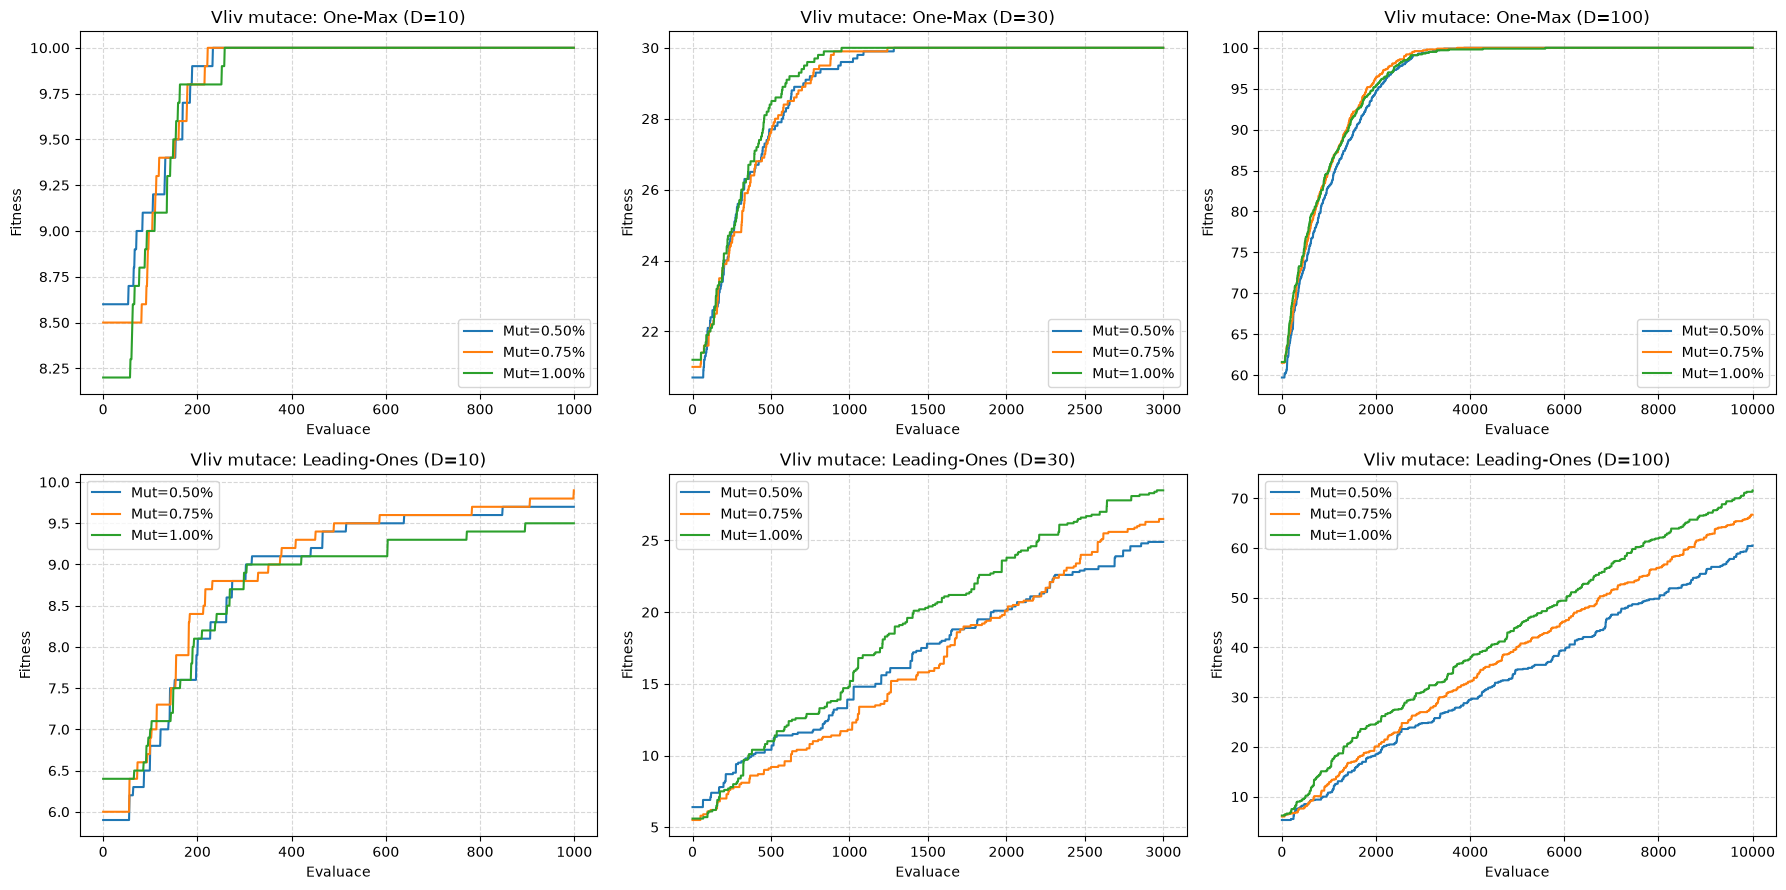

,Problém,Dimenze,Nastavení,Nejlepší,Nejhorší,Průměr,Medián,Směr. odchylka
0,One-Max,10,Mut=0.5%,10,10,10.0,10.0,0.000000
1,One-Max,10,Mut=0.75%,10,10,10.0,10.0,0.000000
2,One-Max,10,Mut=1.0%,10,10,10.0,10.0,0.000000
3,One-Max,30,Mut=0.5%,30,30,30.0,30.0,0.000000
4,One-Max,30,Mut=0.75%,30,30,30.0,30.0,0.000000
5,One-Max,30,Mut=1.0%,30,30,30.0,30.0,0.000000
6,One-Max,100,Mut=0.5%,100,100,100.0,100.0,0.000000
7,One-Max,100,Mut=0.75%,100,100,100.0,100.0,0.000000
8,One-Max,100,Mut=1.0%,100,100,100.0,100.0,0.000000
9,Leading-Ones,10,Mut=0.5%,10,7,9.7,10.0,0.900000


In [5]:
mutation_variants = [0.005, 0.0075, 0.01]
fig, axes = plt.subplots(len(problems), len(dimensions), figsize=(18, 9))
best_mut_results = {}
mut_stats_records = []

for p_idx, (p_name, p_fn) in enumerate(problems.items()):
    for d_idx, dim in enumerate(dimensions):
        max_evals = 100 * dim
        ax = axes[p_idx, d_idx]
        best_mean = -1
        best_cfg = None
        
        for mut_rate in mutation_variants:
            runs_convergence = []
            runs_scores = []
            for _ in range(num_runs):
                conv, best_val = run_genetic_algorithm(
                    fitness_fn=p_fn, dim=dim, max_evals=max_evals,
                    pop_size=50, elite_ratio=0.15, mutation_rate=mut_rate,
                    crossover_rate=0.9, selection_type="rank"
                )
                runs_convergence.append(conv)
                runs_scores.append(best_val)
                
            mean_conv = np.mean(runs_convergence, axis=0)
            ax.plot(mean_conv, label=f"Mut={mut_rate*100:.2f}%")
            
            m_score = np.mean(runs_scores)
            if m_score > best_mean:
                best_mean = m_score
                best_cfg = mut_rate
                
            mut_stats_records.append({
                "Problém": p_name,
                "Dimenze": dim,
                "Nastavení": f"Mut={mut_rate*100}%",
                "Nejlepší": np.max(runs_scores),
                "Nejhorší": np.min(runs_scores),
                "Průměr": np.mean(runs_scores),
                "Medián": np.median(runs_scores),
                "Směr. odchylka": np.std(runs_scores)
            })
                
        best_mut_results[(p_name, dim)] = (best_cfg, best_mean)
        ax.set_title(f"Vliv mutace: {p_name} (D={dim})")
        ax.set_xlabel("Evaluace")
        ax.set_ylabel("Fitness")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend()

plt.tight_layout()
plt.show()

df_mut_stats = pd.DataFrame(mut_stats_records)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
display(df_mut_stats)


## Vliv výběru metody selekce


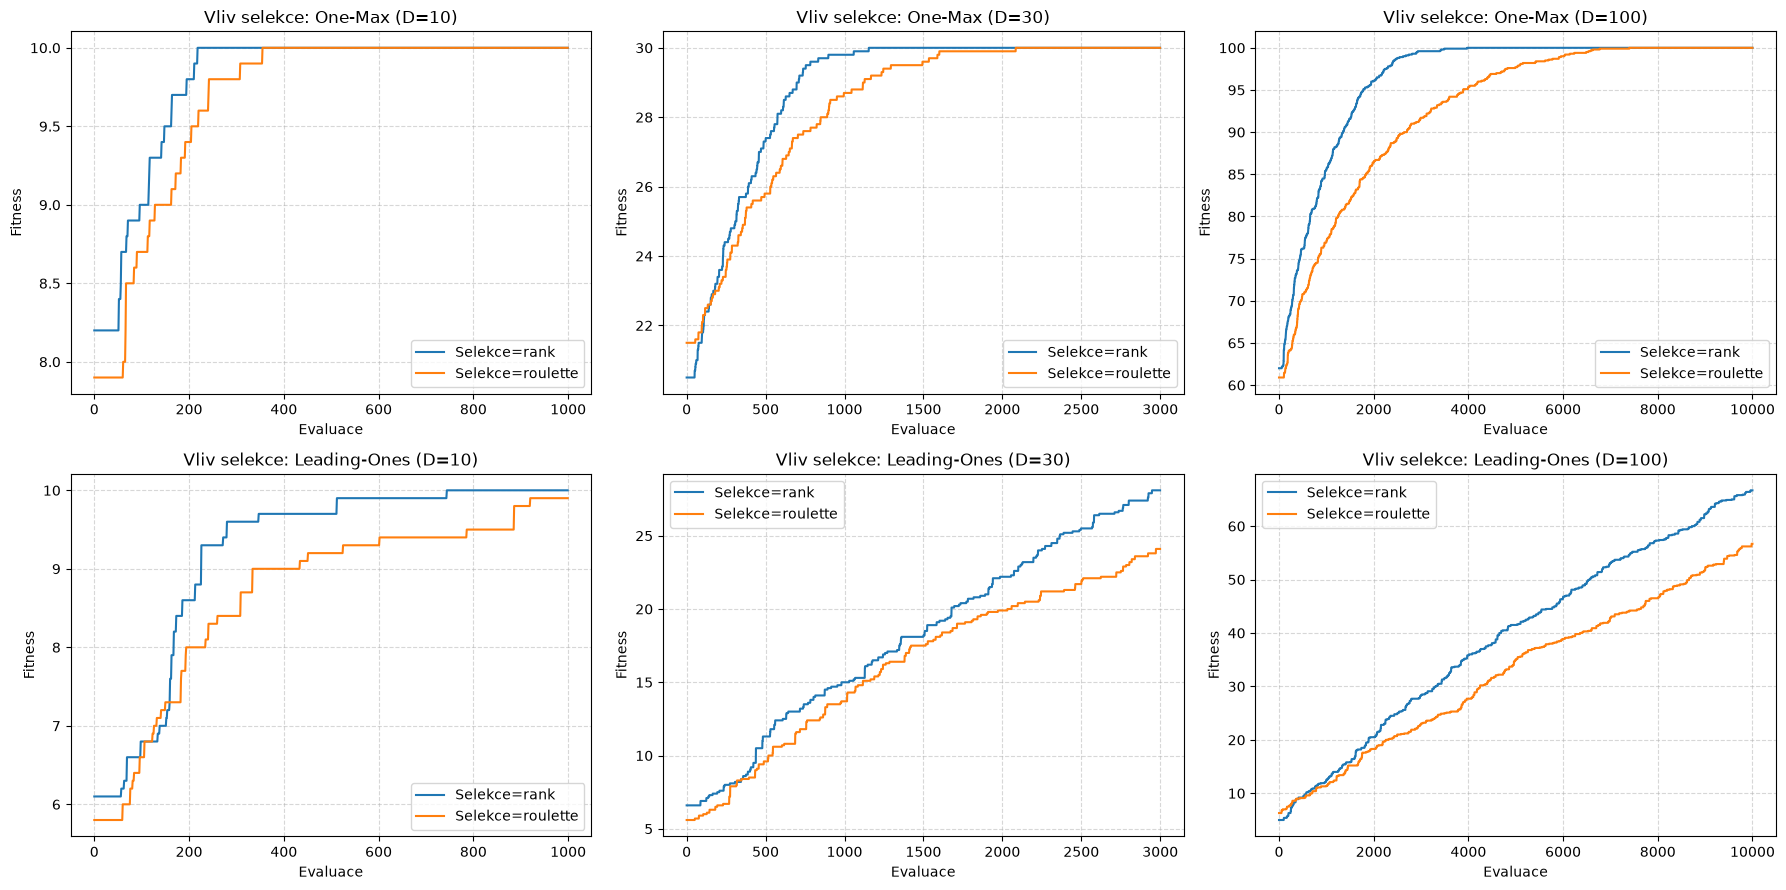

,Problém,Dimenze,Nastavení,Nejlepší,Nejhorší,Průměr,Medián,Směr. odchylka
0,One-Max,10,Selekce=rank,10,10,10.0,10.0,0.000000
1,One-Max,10,Selekce=roulette,10,10,10.0,10.0,0.000000
2,One-Max,30,Selekce=rank,30,30,30.0,30.0,0.000000
3,One-Max,30,Selekce=roulette,30,30,30.0,30.0,0.000000
4,One-Max,100,Selekce=rank,100,100,100.0,100.0,0.000000
5,One-Max,100,Selekce=roulette,100,100,100.0,100.0,0.000000
6,Leading-Ones,10,Selekce=rank,10,10,10.0,10.0,0.000000
7,Leading-Ones,10,Selekce=roulette,10,9,9.9,10.0,0.300000
8,Leading-Ones,30,Selekce=rank,30,21,28.1,30.0,2.844293
9,Leading-Ones,30,Selekce=roulette,30,16,24.1,24.5,3.986226


In [6]:
selection_variants = ["rank", "roulette"]
fig, axes = plt.subplots(len(problems), len(dimensions), figsize=(18, 9))
best_sel_results = {}
sel_stats_records = []

for p_idx, (p_name, p_fn) in enumerate(problems.items()):
    for d_idx, dim in enumerate(dimensions):
        max_evals = 100 * dim
        ax = axes[p_idx, d_idx]
        best_mean = -1
        best_cfg = None
        
        for sel_type in selection_variants:
            runs_convergence = []
            runs_scores = []
            for _ in range(num_runs):
                conv, best_val = run_genetic_algorithm(
                    fitness_fn=p_fn, dim=dim, max_evals=max_evals,
                    pop_size=50, elite_ratio=0.15, mutation_rate=0.01,
                    crossover_rate=0.9, selection_type=sel_type
                )
                runs_convergence.append(conv)
                runs_scores.append(best_val)
                
            mean_conv = np.mean(runs_convergence, axis=0)
            ax.plot(mean_conv, label=f"Selekce={sel_type}")
            
            m_score = np.mean(runs_scores)
            if m_score > best_mean:
                best_mean = m_score
                best_cfg = sel_type
                
            sel_stats_records.append({
                "Problém": p_name,
                "Dimenze": dim,
                "Nastavení": f"Selekce={sel_type}",
                "Nejlepší": np.max(runs_scores),
                "Nejhorší": np.min(runs_scores),
                "Průměr": np.mean(runs_scores),
                "Medián": np.median(runs_scores),
                "Směr. odchylka": np.std(runs_scores)
            })
                
        best_sel_results[(p_name, dim)] = (best_cfg, best_mean)
        ax.set_title(f"Vliv selekce: {p_name} (D={dim})")
        ax.set_xlabel("Evaluace")
        ax.set_ylabel("Fitness")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend()

plt.tight_layout()
plt.show()

df_sel_summary = pd.DataFrame(sel_stats_records)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
display(df_sel_summary)


## Konzervativní multiparametrické nastavení vs optimalizovaného multiparametrické nastavení


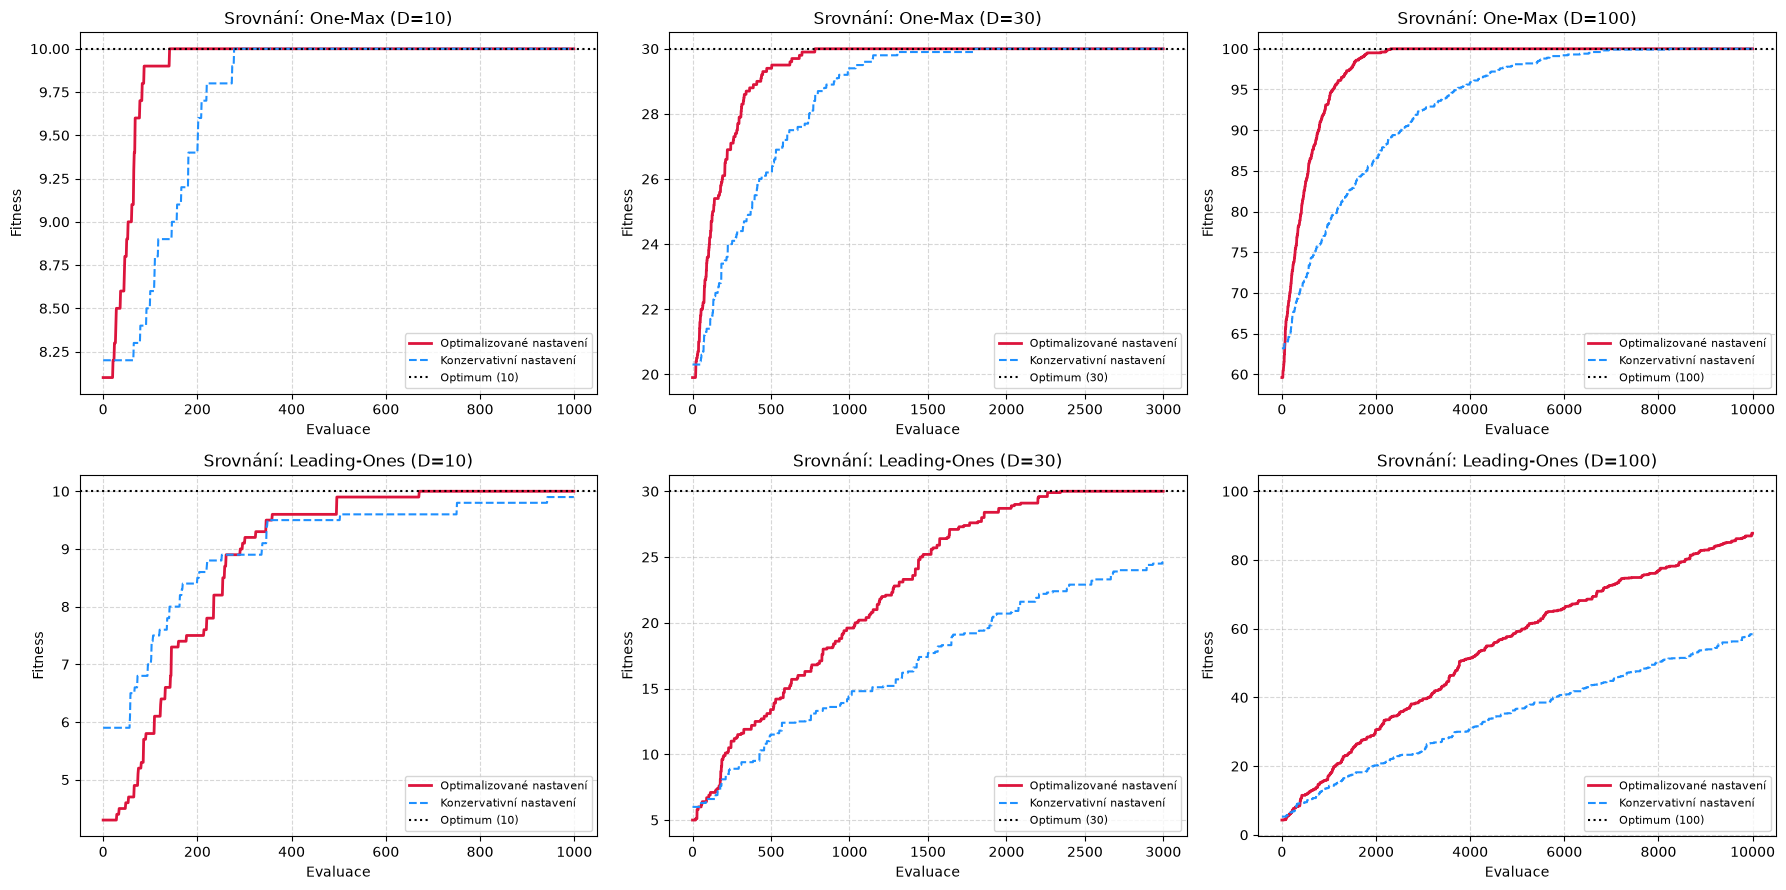

,Problém,Dimenze,Nastavení,Průměr,Medián,Nejlepší,Nejhorší,Směr. odchylka
0,One-Max,10,Optimalizované,10.0,10.0,10,10,0.000000
1,One-Max,10,Konzervativní,10.0,10.0,10,10,0.000000
2,One-Max,30,Optimalizované,30.0,30.0,30,30,0.000000
3,One-Max,30,Konzervativní,30.0,30.0,30,30,0.000000
4,One-Max,100,Optimalizované,100.0,100.0,100,100,0.000000
5,One-Max,100,Konzervativní,100.0,100.0,100,100,0.000000
6,Leading-Ones,10,Optimalizované,10.0,10.0,10,10,0.000000
7,Leading-Ones,10,Konzervativní,9.9,10.0,10,9,0.300000
8,Leading-Ones,30,Optimalizované,30.0,30.0,30,30,0.000000
9,Leading-Ones,30,Konzervativní,24.6,25.5,30,17,5.238320


In [7]:
conservative_params = {
    "pop_size": 50,
    "elite_ratio": 0.15,
    "mutation_rate": 0.0075,
    "crossover_rate": 0.9,
    "selection_type": "roulette"
}

best_params = {
    "pop_size": 20,
    "elite_ratio": 0.20,
    "mutation_rate": 0.01,
    "crossover_rate": 0.9,
    "selection_type": "rank"
}

results_comparison = []
fig, axes = plt.subplots(len(problems), len(dimensions), figsize=(18, 9))

for p_idx, (p_name, p_fn) in enumerate(problems.items()):
    for d_idx, dim in enumerate(dimensions):
        max_evals = 100 * dim
        
        multi_convs, multi_scores = [], []
        for _ in range(num_runs):
            conv, best_val = run_genetic_algorithm(fitness_fn=p_fn, dim=dim, max_evals=max_evals, **best_params)
            multi_convs.append(conv)
            multi_scores.append(best_val)
        mean_multi_conv = np.mean(multi_convs, axis=0)
        
        cons_convs, cons_scores = [], []
        for _ in range(num_runs):
            conv, best_val = run_genetic_algorithm(fitness_fn=p_fn, dim=dim, max_evals=max_evals, **conservative_params)
            cons_convs.append(conv)
            cons_scores.append(best_val)
        mean_cons_conv = np.mean(cons_convs, axis=0)
        
        ax = axes[p_idx, d_idx]
        ax.plot(mean_multi_conv, color="crimson", linewidth=2, label="Optimalizované nastavení")
        ax.plot(mean_cons_conv, color="dodgerblue", linestyle="--", label="Konzervativní nastavení")
        ax.axhline(y=dim, color="black", linestyle=":", label=f"Optimum ({dim})")
        ax.set_title(f"Srovnání: {p_name} (D={dim})")
        ax.set_xlabel("Evaluace")
        ax.set_ylabel("Fitness")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(fontsize=8)

        results_comparison.append({
            "Problém": p_name,
            "Dimenze": dim,
            "Nastavení": "Optimalizované",
            "Průměr": np.mean(multi_scores),
            "Medián": np.median(multi_scores),
            "Nejlepší": np.max(multi_scores),
            "Nejhorší": np.min(multi_scores),
            "Směr. odchylka": np.std(multi_scores)
        })
        results_comparison.append({
            "Problém": p_name,
            "Dimenze": dim,
            "Nastavení": "Konzervativní",
            "Průměr": np.mean(cons_scores),
            "Medián": np.median(cons_scores),
            "Nejlepší": np.max(cons_scores),
            "Nejhorší": np.min(cons_scores),
            "Směr. odchylka": np.std(cons_scores)
        })

plt.tight_layout()
plt.show()

df_summary = pd.DataFrame(results_comparison)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
display(df_summary)


## Závěr

V rámci úlohy jsem implementoval genetický algoritmus s binárním kódováním, jednobodovým křížením, bitovou mutací a elitismem. Testování proběhlo na problémech One-Max a Leading-Ones v dimenzích 10, 30 a 100 při limitu $100 \times D$ evaluací (10 nezávislých běhů pro každé nastavení).

Z naměřených konvergenčních křivek a statistických ukazatelů (min, max, medián, průměr, směrodatná odchylka) lze vyvodit:

* **Vliv velikosti populace:**
  * U malé populace ($N=20$) jsem pozoroval rychlý počáteční růst fitness díky vyššímu počtu generací v daném rozpočtu evaluací. V dimenzi $D=100$ však docházelo k předčasné ztrátě diverzity a uváznutí v lokálním suboptiku.
  * Velká populace ($N=100$) udržuje výbornou genetickou variabilitu, ale při fixním rozpočtu $100 \times D$ stihne projít jen málo generací (v $D=10$ pouze 10 generací), což nestačilo k plné konvergenci.

* **Vliv elitismu:**
  * Zachování přibližně $15\ \%$ nejlepších jedinců bylo naprosto klíčové, zejména u problému Leading-Ones.
  * Bez dostatečného elitismu dochází k destrukci již nalezeného prefixu jedniček křížením a mutací, což vedlo k propadům fitness v průběhu generací.

* **Vliv mutace:**
  * Pravděpodobnost mutace $p_m =$ 1 % fungovala stabilně. 
  * V $D=100$ znamená $p_m =$ 1 % v průměru otočení jednoho bitu za generaci, což umožnilo efektivní lokální prohledávání.

* **Vliv selekce (Rank vs. Ruleta):**
  * **Pořadová selekce (Rank)** jednoznačně překonala ruletovou selekci ve stabilitě i dosažené fitness.
  * Ruleta trpěla v počátečních fázích přílišnou dominancí mírně nadprůměrných jedinců a v závěru naopak nízkým selekčním tlakem. U Leading-Ones v $D=100$ dosáhla ruleta v průměru o znatelně horších výsledků s vyšší směrodatnou odchylkou než Rank.

* **Srovnání nastavení parametrů:**
  * **Konzervativní nastavení:** Velikost populace $N=50$, Rank selekce, mírnější elitismus $15\ \%$, $p_c = 0{,}9$, $p_m = 0{,}01$. Poskytuje stabilnější chování s minimálním rozptylem výsledků (nižší směrodatná odchylka), i když vyžaduje pozvolnější náběh konvergence.
  * **Optimální nastavení pro maximální skóre:** Velikost populace $N=20$, Rank selekce, elitismus $20\ \%$, pravděpodobnost křížení $p_c = 0{,}9$, pravděpodobnost mutace $p_m = 0{,}01$. U One-Max spolehlivě nachází optimum ve všech dimenzích, u Leading-Ones dosahuje nejvyššího průměrného prefixu i v $D=100$.
  